<a href="https://colab.research.google.com/github/harmony-lebovic/image-classifier/blob/main/augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import skimage
from sklearn.model_selection import GroupShuffleSplit
import cv2

## Load data

In [ ]:
# If running on colab you can download the data using gdown. Uncomment the below code.
import gdown

!gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
!gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
!gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
!gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
!gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=506e9a97-661a-4119-be5f-f9f198314c38
To: /content/x_train_img.npz
100% 177M/177M [00:01<00:00, 118MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=ec480cca-da0c-4458-8681-77f749c37170
To: /content/x_test_img.npz
100% 49.0M/49.0M [00:00<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0
To: /content/x_train.csv
100% 160k/160k [00:00<00:00, 19.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8
To: /content/x_test.csv
100% 40.2k/40.2k [00:00<00:00, 67.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg
To: /content

In [ ]:
dev_img_file = "x_train_img.npz"
test_img_file = "x_test_img.npz"

train_metadata_file = "x_train.csv"
test_metadata_file = "x_test.csv"

y_train = "y_train.csv"  # previously "y_file"

In [ ]:
X_dev = pd.read_csv(train_metadata_file)
y_dev = pd.read_csv(y_train)
X_dev

def load_dev_data(train_metadata_file, y_train):
    X_dev = pd.read_csv(train_metadata_file)
    print(f"X_dev loaded from {train_metadata_file}. Shape: {X_dev.shape}. \n")

    y_dev = pd.read_csv(y_train)
    print(f"y_dev loaded from {y_train}. Shape: {y_dev.shape}. \n")

    return X_dev, y_dev

In [ ]:
X_test = pd.read_csv(test_metadata_file)
X_test

def load_test_data(test_metadata_file):
    X_test = pd.read_csv(test_metadata_file)
    print(f"X_test loaded from {test_metadata_file}. Shape: {X_test.shape}. \n")
    return X_test

In [ ]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")
    return img, ids

dev_imgs, dev_img_ids = load_img_data(dev_img_file)
test_imgs, test_img_ids = load_img_data(test_img_file)
print(dev_img_ids.shape, dev_imgs.shape)
print(test_img_ids.shape, test_imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(dev_img_ids == X_dev['img_id']), "Image IDs in train metadata and image data do not match"
assert np.all(test_img_ids == X_test['img_id']), "Images IDs in test metadata and image data do not match"

Successfully loaded 1178 images.
Successfully loaded 296 images.
(1178,) (1178, 256, 256, 3)
(296,) (296, 256, 256, 3)


In [ ]:
SEED = 101

## GroupShuffleSplit and age groupings

In [ ]:
# Generate groups patient ids
pat_ids = X_dev['patient_id'].drop_duplicates()
pat_ids['group'] = range(0, len(pat_ids))

x_train_groupings = pd.merge(X_dev, pat_ids, on=['patient_id'], how='left')

# Extract groups
groups = x_train_groupings['patient_id'].values

# Split using GroupShuffleSplit
split = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
split.get_n_splits()

# Capture training and validation indices
train_idx, val_idx = next(split.split(X_dev, y_dev, groups))

# Separate training and validation sets
X_train = X_dev.iloc[train_idx]
X_val = X_dev.iloc[val_idx]
y_train = y_dev.iloc[train_idx]
y_val = y_dev.iloc[val_idx]

# Capture groupings in training and validation sets
train_groups = groups[train_idx]
val_groups = groups[val_idx]

# Determine if there are any overlapping groups
shared_groups = list(set(train_groups) & set(val_groups))
print(shared_groups)

[]


In [ ]:
# Development set
dev_age_groups = pd.cut(
    X_dev['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

In [ ]:
# Test set
test_age_groups = pd.cut(
    X_test['age'],
    bins=[0, 30, 60, 100],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

## Anonymize development and test set

In [ ]:
# Remove patient and image ids from training and validation sets
X_train_clean = X_train.drop(columns=['patient_id', 'img_id'])
X_val_clean = X_val.drop(columns=['patient_id', 'img_id'])
y_train_clean = y_train['coarse_label']
y_val_clean = y_val['coarse_label']

# Remove patient and image ids from test set
X_test_clean = X_test.drop(columns=['patient_id', 'img_id'])

# Remove patient and image ids from development set
X_dev_clean = X_dev.drop(columns=['patient_id', 'img_id'])
y_dev_clean = pd.DataFrame(y_dev['coarse_label'])

In [ ]:
# Add age group column
X_dev_clean['age_group'] = dev_age_groups
y_dev_clean['age_group'] = dev_age_groups

X_test_clean['age_group'] = test_age_groups

In [ ]:
# Determine class balance within senior group
print(len(X_dev_clean))
print(len(X_dev_clean[X_dev_clean['age_group'] == 'Senior (60+)']))

1178
676


## Make images grayscale

In [ ]:
dev_imgs_gray = np.empty((1178, 1, 256, 256))

# Convert images to grayscale
for i, img in enumerate(dev_imgs):
  dev_imgs_gray[i] = cv2.cvtColor(dev_imgs[i], cv2.COLOR_BGR2GRAY)
  dev_imgs_gray[i][np.newaxis, :]
  # print(f'Image {i} complete.')

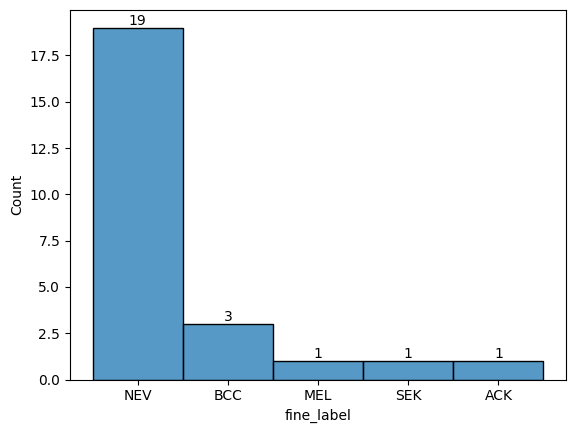

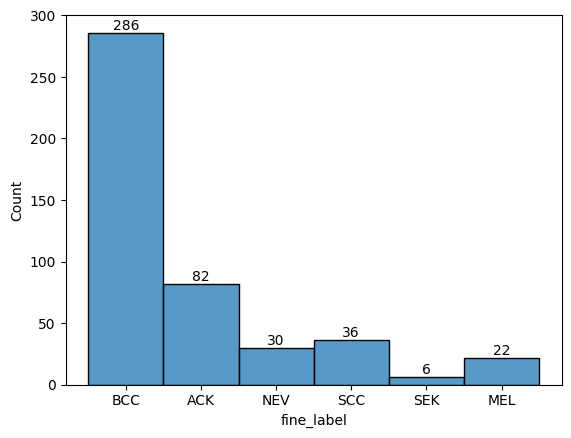

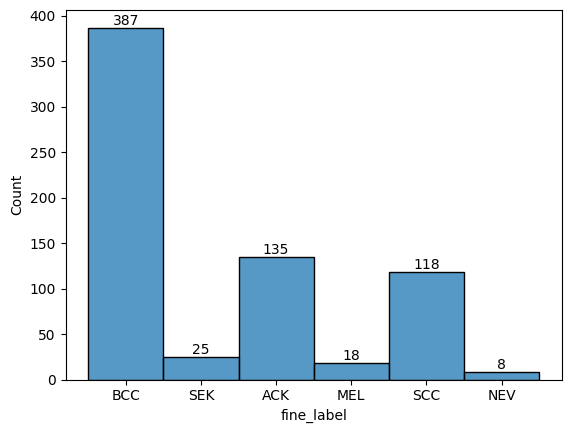

In [ ]:
# Create age group column in y_dev
# Don't run this one if doing training because it messses it up

# Deduplicate copy of X_dev
X_dev_deduplicated = X_dev.drop_duplicates(subset='patient_id', inplace=False)
age_lookup = X_dev_deduplicated.set_index('patient_id')['age']

# Map age from X_dev onto y_dev via patient_id
y_dev['age'] = y_dev['patient_id'].map(age_lookup)

# Bin into age groups
y_dev['age_group'] = pd.cut(
    y_dev['age'],
    bins=[0, 30, 60, float('inf')],
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)'],
    right=False
)

# Plot data
#sns.histplot(data=y_dev, x="age_group", hue="fine_label", multiple="stack")

# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Young (<30)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()


# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Adult (30-60)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()


# Plot data
ax = sns.histplot(data=y_dev[y_dev['age_group']=='Senior (60+)'], x="fine_label", multiple="stack")

for container in ax.containers:
    ax.bar_label(container)
plt.show()

# Remove column after displaying plot
#y_dev.drop(columns=['age_group'], inplace=True)

## Perform image rotation

In [ ]:
# cols-1 and rows-1 are the coordinate limits.
img = dev_imgs_gray[0][0,:,:]
img.shape
rows, cols = img.shape

M = cv2.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
dst = cv2.warpAffine(img,M,(cols,rows))

In [ ]:
X_dev.head()
y_dev.head()

,patient_id,img_id,coarse_label,fine_label,age,age_group
0,PAT_620,PAT_620_001,1,BCC,55,Adult (30-60)
1,PAT_388,PAT_388_002,1,BCC,79,Senior (60+)
2,PAT_518,PAT_518_003,1,BCC,52,Adult (30-60)
3,PAT_635,PAT_635_004,1,BCC,74,Senior (60+)
4,PAT_447,PAT_447_005,1,ACK,58,Adult (30-60)


In [ ]:
# Create pt indexes for SEK, NEV for seniors
senior_benign = y_dev[(y_dev['age_group'] == 'Senior (60+)') & (y_dev['coarse_label'] == 0)]
senior_benign_idx = senior_benign.index.values

imgs = dev_imgs_gray[senior_benign_idx][0, :, :]

# Define function to rotate images

In [ ]:
# Define function to rotate images
def rotate_image(img, angle):
  rows, cols = img.shape
  M = cv2.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
  rotated_image = cv2.warpAffine(img,M,(cols,rows))
  return rotated_image


# Define function to flip images
def flip_image(img, flip):
  # flip = 0 does vertical flip
  # flip > 0 does horizontal flip
  flipped_image = cv2.flip(img, flip)

  return flipped_image

# Function to apply augmentations to different classes

In [29]:
# Apply augmentations
# Define function to rotate images
def rotate_image(img, angle):
    rows, cols = img.shape
    M = cv2.getRotationMatrix2D(((cols-1)/2.0, (rows-1)/2.0), angle, 1)
    return cv2.warpAffine(img, M, (cols, rows))

# Define function to flip images
def flip_image(img, flip):
    # flip = 0 does vertical flip
    # flip > 0 does horizontal flip
    return cv2.flip(img, flip)

def augment_class(fine_label, angles, flips):
    senior_idx = y_dev[
        (y_dev['age_group'] == 'Senior (60+)') & (y_dev['fine_label'] == fine_label)
    ].index.values

    for orig_idx in senior_idx:
        img_2d = dev_imgs_gray[orig_idx][0, :, :]

        for angle in angles:
            for flip in flips:
                aug = rotate_image(img_2d, angle)
                if flip is not None:
                    aug = flip_image(aug, flip)

                aug_imgs_list.append(aug[np.newaxis])

                for rows_list, df in [(aug_X_rows, X_dev), (aug_y_rows, y_dev)]:
                    row = df.iloc[orig_idx].copy()
                    row['img_id'] = f"{row['img_id']}_rot{angle}_flip{flip}"
                    rows_list.append(row)

aug_imgs_list, aug_X_rows, aug_y_rows = [], [], []

# NEV: 4 angles x 2 flips = 8 transforms
augment_class('NEV', angles=[0, 90, 180, 270], flips=[0, 1])

# MEL: 3 angles x 2 flips = 6 transforms
augment_class('MEL', angles=[0, 90, 180], flips=[0, 1])

# SEK: 3 rotations
augment_class('SEK', angles=[90, 180, 270], flips=[None])

# Concatenate with originals
dev_imgs_gray_aug = np.concatenate([dev_imgs_gray, np.stack(aug_imgs_list)], axis=0)
X_dev_aug = pd.concat([X_dev, pd.DataFrame(aug_X_rows)], ignore_index=True)
y_dev_aug = pd.concat([y_dev, pd.DataFrame(aug_y_rows)], ignore_index=True)

print(f"Original: {len(dev_imgs_gray)} | New: {len(aug_imgs_list)} | Total: {len(dev_imgs_gray_aug)}")

Original: 1178 | New: 247 | Total: 1425


In [ ]:
# Reshuffle

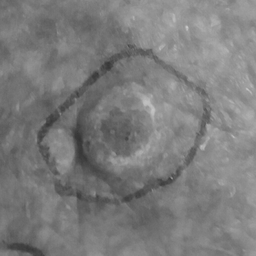

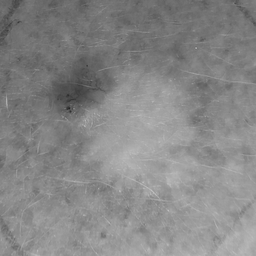

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)
cv2_imshow(dst)